# 03h — Sensitivity of Minimum RZSM Decline Rate: **5 vs 7.5 vs 10 pp pentad⁻¹**

This notebook adds the missing **decline-rate sensitivity** dimension.

## Question

Does the main Indonesian flash-drought conclusion remain stable when the
minimum mean P40→P20 decline rate is made stricter?

Configurations:

- `RATE5` = **5.0 percentile points pentad⁻¹** — current M2A benchmark;
- `RATE7P5` = **7.5 percentile points pentad⁻¹**;
- `RATE10` = **10.0 percentile points pentad⁻¹**.

All other M2A criteria are held constant:

- start ≥P40;
- reach <P20;
- maximum onset = 5 pentads;
- strict monotonic decline;
- minimum detected episode duration = 4 pentad intervals;
- initial consecutive persistence <P20 = 3 pentads;
- recovery = 1 pentad ≥P20.

`RATE5` reuses the existing M2A file. `RATE7P5` and `RATE10` are **redetected**
from the exact-pentad percentile cube; they are not produced by simply filtering
RATE5 events by stored onset speed.

## Scientific role

This is a **definition-sensitivity / robustness test**. The values 7.5 and 10
are intentionally stricter perturbations around the 5 pp pentad⁻¹ benchmark.
Do not select a rate because it gives a preferred event count, trend, or map.


In [1]:
from pathlib import Path
import json
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import dask.array as da
import matplotlib.pyplot as plt
from scipy import stats

try:
    from dask.diagnostics import ProgressBar
except Exception:
    ProgressBar = None

warnings.filterwarnings("once")

RZSM_DIR = Path(
    r"D:\ERA5_LAND\output_rzsm"
)

PERCENTILE_FILE = (
    RZSM_DIR
    / "rzsm_percentile_gringorten_1995_2025.nc"
)

BASELINE_FILE = Path(
    r"D:\ERA5_LAND\output_fd_03b_sensitivity\fd_detection_M2A_1995_2025_indonesia.nc"
)

OUTPUT_DIR = Path(
    r"D:\ERA5_LAND\output_fd_03h_rate_sensitivity"
)
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

START_THRESHOLD = 40.0
DROUGHT_THRESHOLD = 20.0
MIN_TOTAL_DURATION = 4
STRICT_MONOTONIC = True

MAX_ONSET_PENTADS = 5
PERSISTENCE_PENTADS = 3
RECOVERY_PENTADS = 1

RATE_VALUES = [5.0, 7.5, 10.0]
BASELINE_RATE = 5.0

ANALYSIS_START = 1996
ANALYSIS_END = 2024

LAT_CHUNK = 15
LON_CHUNK = 40
TIME_CHUNK_OUTPUT = 73
FIG_DPI = 300

FORCE_RERUN = False

try:
    import h5netcdf  # noqa
    NETCDF_ENGINE = "h5netcdf"
except Exception:
    NETCDF_ENGINE = "netcdf4"

for path in [
    PERCENTILE_FILE,
    BASELINE_FILE,
]:
    if not path.exists():
        raise FileNotFoundError(path)

print("NetCDF engine:", NETCDF_ENGINE)
print("Decline-rate sensitivity:", RATE_VALUES)


NetCDF engine: h5netcdf
Decline-rate sensitivity: [5.0, 7.5, 10.0]


In [2]:
from numba import njit

@njit
def detect_one_series_robustness(
    p,
    start_threshold,
    drought_threshold,
    min_decline_rate,
    min_total_duration,
    strict_monotonic,
    max_onset_pentads,
    min_below_p20_pentads,
    recovery_consecutive_pentads,
):
    # Reduced-output reproduction of the 03b event engine.
    n = p.size

    event_start = np.zeros(n, dtype=np.int8)
    drought_core = np.zeros(n, dtype=np.int8)

    duration = np.full(n, -1, dtype=np.int16)
    onset_time = np.full(n, -1, dtype=np.int16)
    below_p20_duration = np.full(n, -1, dtype=np.int16)

    onset_speed = np.full(n, np.nan, dtype=np.float32)
    severity40 = np.full(n, np.nan, dtype=np.float32)
    minimum_percentile = np.full(n, np.nan, dtype=np.float32)

    i = 0

    while i < n - 1:
        if np.isnan(p[i]) or np.isnan(p[i + 1]):
            i += 1
            continue

        # Same baseline logic used by 03b.
        if not (
            p[i] >= start_threshold
            and p[i + 1] < start_threshold
        ):
            i += 1
            continue

        baseline = i
        crossing = -1
        j = baseline + 1

        while j < n:
            if np.isnan(p[j]) or np.isnan(p[j - 1]):
                break

            if (
                max_onset_pentads > 0
                and (j - baseline) > max_onset_pentads
            ):
                break

            if strict_monotonic and not (p[j] < p[j - 1]):
                break

            if p[j] < drought_threshold:
                crossing = j
                break

            j += 1

        if crossing < 0:
            i += 1
            continue

        current_onset_time = crossing - baseline
        current_onset_speed = (
            p[baseline] - p[crossing]
        ) / current_onset_time

        if current_onset_speed < min_decline_rate:
            i += 1
            continue

        # Same recovery logic as 03b.
        termination = -1
        missing_during_event = False
        above_run = 0
        above_run_start = -1
        k = crossing + 1

        while k < n:
            if np.isnan(p[k]):
                missing_during_event = True
                break

            if p[k] >= drought_threshold:
                if above_run == 0:
                    above_run_start = k

                above_run += 1

                if above_run >= recovery_consecutive_pentads:
                    termination = above_run_start
                    break
            else:
                above_run = 0
                above_run_start = -1

            k += 1

        if missing_during_event:
            i = k + 1
            continue

        # Right-censored event.
        if termination < 0:
            break

        total_duration = termination - baseline

        initial_below_p20_run = 0
        q = crossing
        while (
            q < termination
            and p[q] < drought_threshold
        ):
            initial_below_p20_run += 1
            q += 1

        if total_duration < min_total_duration:
            i = termination
            continue

        if (
            initial_below_p20_run
            < min_below_p20_pentads
        ):
            i = termination
            continue

        min_value = p[crossing]
        sev40 = 0.0

        for q in range(baseline + 1, termination):
            if p[q] < min_value:
                min_value = p[q]

            if p[q] < start_threshold:
                sev40 += start_threshold - p[q]

        event_start[baseline] = 1
        duration[baseline] = total_duration
        onset_time[baseline] = current_onset_time
        below_p20_duration[baseline] = initial_below_p20_run
        onset_speed[baseline] = current_onset_speed
        severity40[baseline] = sev40
        minimum_percentile[baseline] = min_value

        for q in range(crossing, termination):
            if p[q] < drought_threshold:
                drought_core[q] = 1

        i = termination

    return (
        event_start,
        drought_core,
        duration,
        onset_time,
        below_p20_duration,
        onset_speed,
        severity40,
        minimum_percentile,
    )


@njit
def detect_block_robustness(
    p_block,
    start_threshold,
    drought_threshold,
    min_decline_rate,
    min_total_duration,
    strict_monotonic,
    max_onset_pentads,
    min_below_p20_pentads,
    recovery_consecutive_pentads,
):
    original_shape = p_block.shape
    nt = original_shape[-1]
    npixel = p_block.size // nt
    flat = p_block.reshape((npixel, nt))

    event_start = np.zeros((npixel, nt), dtype=np.int8)
    drought_core = np.zeros((npixel, nt), dtype=np.int8)

    duration = np.full((npixel, nt), -1, dtype=np.int16)
    onset_time = np.full((npixel, nt), -1, dtype=np.int16)
    below_p20_duration = np.full((npixel, nt), -1, dtype=np.int16)

    onset_speed = np.full((npixel, nt), np.nan, dtype=np.float32)
    severity40 = np.full((npixel, nt), np.nan, dtype=np.float32)
    minimum_percentile = np.full((npixel, nt), np.nan, dtype=np.float32)

    for pixel in range(npixel):
        r = detect_one_series_robustness(
            flat[pixel],
            start_threshold,
            drought_threshold,
            min_decline_rate,
            min_total_duration,
            strict_monotonic,
            max_onset_pentads,
            min_below_p20_pentads,
            recovery_consecutive_pentads,
        )

        event_start[pixel] = r[0]
        drought_core[pixel] = r[1]
        duration[pixel] = r[2]
        onset_time[pixel] = r[3]
        below_p20_duration[pixel] = r[4]
        onset_speed[pixel] = r[5]
        severity40[pixel] = r[6]
        minimum_percentile[pixel] = r[7]

    return (
        event_start.reshape(original_shape),
        drought_core.reshape(original_shape),
        duration.reshape(original_shape),
        onset_time.reshape(original_shape),
        below_p20_duration.reshape(original_shape),
        onset_speed.reshape(original_shape),
        severity40.reshape(original_shape),
        minimum_percentile.reshape(original_shape),
    )


OUTPUT_NAMES = [
    "fd_event_start",
    "fd_drought_core",
    "duration_pentads_at_start",
    "onset_time_pentads_at_start",
    "below_p20_pentads_at_start",
    "onset_speed_at_start",
    "severity_p40_at_start",
    "minimum_percentile_at_start",
]

OUTPUT_DTYPES = [
    np.int8,
    np.int8,
    np.int16,
    np.int16,
    np.int16,
    np.float32,
    np.float32,
    np.float32,
]


def percentile_to_time_index(pct):
    required = {
        "year",
        "pentad",
        "latitude",
        "longitude",
    }
    if not required.issubset(pct.dims):
        raise ValueError(
            f"Percentile dims must contain {required}; "
            f"found {pct.dims}"
        )

    pct = pct.transpose(
        "year",
        "pentad",
        "latitude",
        "longitude",
    )

    years = np.asarray(
        pct["year"].values,
        dtype=np.int16,
    )
    pentads = np.asarray(
        pct["pentad"].values,
        dtype=np.int16,
    )

    stacked = (
        pct.stack(time_index=("year", "pentad"))
        .transpose(
            "latitude",
            "longitude",
            "time_index",
        )
        .reset_index(
            "time_index",
            drop=True,
        )
    )

    year_step = np.repeat(
        years,
        len(pentads),
    ).astype(np.int16)

    pentad_step = np.tile(
        pentads,
        len(years),
    ).astype(np.int16)

    stacked = stacked.assign_coords(
        time_index=(
            "time_index",
            np.arange(
                stacked.sizes["time_index"],
                dtype=np.int32,
            ),
        ),
        year=("time_index", year_step),
        pentad=("time_index", pentad_step),
    )

    expected_year = np.repeat(years, len(pentads)).astype(np.int16)
    expected_pentad = np.tile(pentads, len(years)).astype(np.int16)

    if not np.array_equal(stacked["year"].values, expected_year):
        raise ValueError("Stacked year coordinate is not in year-major order.")
    if not np.array_equal(stacked["pentad"].values, expected_pentad):
        raise ValueError("Stacked pentad coordinate is not in year-major order.")

    return stacked.chunk({
        "latitude": LAT_CHUNK,
        "longitude": LON_CHUNK,
        "time_index": -1,
    })


def build_detection(
    pct_time,
    valid,
    label,
    decline_rate,
    max_onset,
    persistence,
    recovery=1,
):
    result = xr.apply_ufunc(
        detect_block_robustness,
        pct_time,
        input_core_dims=[["time_index"]],
        output_core_dims=[
            ["time_index"]
            for _ in OUTPUT_NAMES
        ],
        vectorize=False,
        dask="parallelized",
        output_dtypes=OUTPUT_DTYPES,
        kwargs={
            "start_threshold": START_THRESHOLD,
            "drought_threshold": DROUGHT_THRESHOLD,
            "min_decline_rate": float(decline_rate),
            "min_total_duration": MIN_TOTAL_DURATION,
            "strict_monotonic": STRICT_MONOTONIC,
            "max_onset_pentads": int(max_onset),
            "min_below_p20_pentads": int(persistence),
            "recovery_consecutive_pentads": int(recovery),
        },
        dask_gufunc_kwargs={
            "allow_rechunk": False,
        },
    )

    data_vars = {}

    for arr, name, dtype in zip(
        result,
        OUTPUT_NAMES,
        OUTPUT_DTYPES,
    ):
        arr = arr.rename(name).transpose(
            "time_index",
            "latitude",
            "longitude",
        )

        if name in [
            "fd_event_start",
            "fd_drought_core",
        ]:
            arr = arr.where(
                valid,
                other=0,
            ).astype(dtype)
        elif np.issubdtype(
            np.dtype(dtype),
            np.integer,
        ):
            arr = arr.where(
                valid,
                other=-1,
            ).astype(dtype)
        else:
            arr = arr.where(valid).astype(dtype)

        data_vars[name] = arr

    out = xr.Dataset(data_vars)
    out["valid_grid_mask"] = valid.astype(np.int8)

    out.attrs.update({
        "variant": label,
        "start_threshold_percentile": START_THRESHOLD,
        "drought_threshold_percentile": DROUGHT_THRESHOLD,
        "minimum_mean_decline_rate_pp_per_pentad": float(decline_rate),
        "minimum_total_duration_pentad_intervals": MIN_TOTAL_DURATION,
        "strict_monotonic_onset": str(STRICT_MONOTONIC),
        "maximum_onset_pentads": int(max_onset),
        "minimum_initial_consecutive_below_p20_pentads": int(persistence),
        "recovery_consecutive_pentads": int(recovery),
        "right_censored_events": "excluded",
        "purpose": "definition sensitivity / robustness",
    })

    return out


def detection_encoding(ds):
    enc = {}

    for name, var in ds.data_vars.items():
        cfg = {
            "zlib": True,
            "complevel": 4,
            "shuffle": True,
        }

        if var.dims == (
            "time_index",
            "latitude",
            "longitude",
        ):
            cfg["chunksizes"] = (
                TIME_CHUNK_OUTPUT,
                min(
                    LAT_CHUNK,
                    var.sizes["latitude"],
                ),
                min(
                    LON_CHUNK,
                    var.sizes["longitude"],
                ),
            )
        elif var.dims == (
            "latitude",
            "longitude",
        ):
            cfg["chunksizes"] = (
                min(
                    LAT_CHUNK,
                    var.sizes["latitude"],
                ),
                min(
                    LON_CHUNK,
                    var.sizes["longitude"],
                ),
            )

        if np.issubdtype(
            var.dtype,
            np.floating,
        ):
            cfg["_FillValue"] = np.float32(np.nan)
        else:
            cfg["_FillValue"] = None

        enc[name] = cfg

    return enc


def write_detection(
    pct_time,
    valid,
    output_file,
    label,
    decline_rate,
    max_onset,
    persistence,
    recovery=1,
    force=False,
):
    if output_file.exists() and not force:
        print("Using existing:", output_file)
        return output_file

    if output_file.exists():
        output_file.unlink()

    lazy = build_detection(
        pct_time=pct_time,
        valid=valid,
        label=label,
        decline_rate=decline_rate,
        max_onset=max_onset,
        persistence=persistence,
        recovery=recovery,
    )

    for name in lazy.variables:
        lazy[name].encoding = {}

    print("Writing:", output_file)

    if ProgressBar is not None:
        with ProgressBar():
            lazy.to_netcdf(
                output_file,
                engine=NETCDF_ENGINE,
                encoding=detection_encoding(lazy),
            )
    else:
        lazy.to_netcdf(
            output_file,
            engine=NETCDF_ENGINE,
            encoding=detection_encoding(lazy),
        )

    print("Saved:", output_file)
    return output_file


In [3]:
def subset_analysis(ds):
    y = np.asarray(
        ds["year"].values,
        dtype=int,
    )
    idx = np.flatnonzero(
        (y >= ANALYSIS_START)
        & (y <= ANALYSIS_END)
    )
    if idx.size == 0:
        raise ValueError("No analysis years found.")
    return ds.isel(time_index=idx)


def cosine_weights(valid):
    wlat = xr.DataArray(
        np.cos(
            np.deg2rad(
                valid["latitude"].values
            )
        ),
        coords={
            "latitude": valid["latitude"]
        },
        dims=("latitude",),
    )
    return (
        wlat
        * xr.ones_like(
            valid,
            dtype=np.float32,
        )
    ).where(valid)


def jaccard(a, b):
    calc = xr.Dataset({
        "intersection": (a & b).sum(),
        "union": (a | b).sum(),
    }).compute()

    union = float(calc["union"])
    if union == 0:
        return np.nan

    return float(calc["intersection"]) / union


def summarize_detection(ds, valid, name):
    d = subset_analysis(ds)

    start = (
        d["fd_event_start"] == 1
    ).where(valid, False)

    core = (
        d["fd_drought_core"] == 1
    ).where(valid, False)

    weights = cosine_weights(valid)
    denominator = weights.sum()

    n_years = (
        ANALYSIS_END
        - ANALYSIS_START
        + 1
    )

    start_count = int(
        start.sum().compute()
    )
    affected_grid = int(
        start.any("time_index")
        .sum()
        .compute()
    )

    freq_count = (
        start.sum("time_index")
        .compute()
        .where(valid)
    )

    onset_area = (
        (
            start.astype(np.float32)
            * weights
        )
        .sum(("latitude", "longitude"))
        / denominator
        * 100.0
    )

    core_area = (
        (
            core.astype(np.float32)
            * weights
        )
        .sum(("latitude", "longitude"))
        / denominator
        * 100.0
    )

    area = xr.Dataset({
        "onset": onset_area,
        "core": core_area,
    }).compute()

    years = np.asarray(
        d["year"].values,
        dtype=int,
    )

    annual_rows = []

    for yr in range(
        ANALYSIS_START,
        ANALYSIS_END + 1,
    ):
        mask = years == yr

        annual_rows.append({
            "method": name,
            "year": int(yr),
            "annual_onset_exposure_area_percent_pentad": float(
                np.nansum(
                    area["onset"].values[mask]
                )
            ),
            "maximum_new_onset_area_percent": float(
                np.nanmax(
                    area["onset"].values[mask]
                )
            ),
            "maximum_drought_core_area_percent": float(
                np.nanmax(
                    area["core"].values[mask]
                )
            ),
        })

    characteristic_rows = []

    for var in [
        "onset_speed_at_start",
        "onset_time_pentads_at_start",
        "duration_pentads_at_start",
        "below_p20_pentads_at_start",
        "severity_p40_at_start",
        "minimum_percentile_at_start",
    ]:
        vals = (
            d[var]
            .where(start)
            .stack(
                sample=(
                    "time_index",
                    "latitude",
                    "longitude",
                )
            )
            .dropna("sample")
            .compute()
            .values
        )

        characteristic_rows.append({
            "method": name,
            "variable": var,
            "n": int(vals.size),
            "mean": (
                float(np.mean(vals))
                if vals.size
                else np.nan
            ),
            "median": (
                float(np.median(vals))
                if vals.size
                else np.nan
            ),
            "q25": (
                float(np.quantile(vals, 0.25))
                if vals.size
                else np.nan
            ),
            "q75": (
                float(np.quantile(vals, 0.75))
                if vals.size
                else np.nan
            ),
        })

    summary = {
        "method": name,
        "gridcell_event_starts_1996_2024": start_count,
        "affected_grid_count": affected_grid,
        "affected_grid_percent": (
            100.0
            * affected_grid
            / int(valid.sum().item())
        ),
        "mean_events_per_decade_valid_grid": float(
            (
                freq_count
                / n_years
                * 10.0
            )
            .where(valid)
            .mean()
        ),
        "maximum_events_per_decade": float(
            (
                freq_count
                / n_years
                * 10.0
            )
            .where(valid)
            .max()
        ),
    }

    return (
        summary,
        pd.DataFrame(annual_rows),
        pd.DataFrame(characteristic_rows),
        freq_count,
    )


def compare_variant(
    baseline,
    variant,
    valid,
    baseline_name,
    variant_name,
):
    b = subset_analysis(baseline)
    v = subset_analysis(variant)

    bstart = (
        b["fd_event_start"] == 1
    ).where(valid, False)

    vstart = (
        v["fd_event_start"] == 1
    ).where(valid, False)

    bcore = (
        b["fd_drought_core"] == 1
    ).where(valid, False)

    vcore = (
        v["fd_drought_core"] == 1
    ).where(valid, False)

    start_j = jaccard(bstart, vstart)
    core_j = jaccard(bcore, vcore)

    bf = (
        bstart.sum("time_index")
        .compute()
        .where(valid)
    )
    vf = (
        vstart.sum("time_index")
        .compute()
        .where(valid)
    )

    x = bf.values[valid.values]
    y = vf.values[valid.values]

    ok = (
        np.isfinite(x)
        & np.isfinite(y)
    )

    if ok.sum() > 2:
        sr, sp = stats.spearmanr(
            x[ok],
            y[ok],
        )
        pr, pp = stats.pearsonr(
            x[ok],
            y[ok],
        )
    else:
        sr = sp = pr = pp = np.nan

    bq90 = np.nanquantile(
        x[ok],
        0.90,
    )
    vq90 = np.nanquantile(
        y[ok],
        0.90,
    )

    bhot = (
        bf >= bq90
    ).where(valid, False)

    vhot = (
        vf >= vq90
    ).where(valid, False)

    return {
        "baseline": baseline_name,
        "variant": variant_name,
        "event_start_jaccard": start_j,
        "drought_core_jaccard": core_j,
        "frequency_spearman_r": float(sr),
        "frequency_spearman_p": float(sp),
        "frequency_pearson_r": float(pr),
        "frequency_pearson_p": float(pp),
        "q90_hotspot_jaccard": jaccard(
            bhot,
            vhot,
        ),
    }


In [4]:
baseline = xr.open_dataset(
    BASELINE_FILE,
    chunks={
        "time_index": 73,
        "latitude": LAT_CHUNK,
        "longitude": LON_CHUNK,
    },
    mask_and_scale=False,
)

valid = (
    baseline["valid_grid_mask"] == 1
).compute()

pct_ds = xr.open_dataset(
    PERCENTILE_FILE,
    chunks={
        "year": -1,
        "pentad": -1,
        "latitude": LAT_CHUNK,
        "longitude": LON_CHUNK,
    },
)

pct = (
    pct_ds["rzsm_percentile"]
    .where(valid)
)

pct_time = percentile_to_time_index(
    pct
)

# Exact ordering agreement with the existing M2A time axis.
expected_year = np.repeat(
    np.asarray(pct["year"].values, dtype=int),
    pct.sizes["pentad"],
)
expected_pentad = np.tile(
    np.asarray(pct["pentad"].values, dtype=int),
    pct.sizes["year"],
)

if not np.array_equal(
    np.asarray(baseline["year"].values, dtype=int),
    expected_year,
):
    raise ValueError(
        "Baseline detection year coordinate differs from percentile year-major ordering."
    )

if not np.array_equal(
    np.asarray(baseline["pentad"].values, dtype=int),
    expected_pentad,
):
    raise ValueError(
        "Baseline detection pentad coordinate differs from percentile year-major ordering."
    )

variant_files = {}

for rate in [7.5, 10.0]:
    tag = str(rate).replace(".", "p")

    out_file = (
        OUTPUT_DIR
        / f"fd_robustness_rate{tag}_onset5_persist3.nc"
    )

    write_detection(
        pct_time=pct_time,
        valid=valid,
        output_file=out_file,
        label=f"RATE{tag}_ONSET5_PERSIST3",
        decline_rate=rate,
        max_onset=MAX_ONSET_PENTADS,
        persistence=PERSISTENCE_PENTADS,
        recovery=RECOVERY_PENTADS,
        force=FORCE_RERUN,
    )

    variant_files[rate] = out_file

datasets = {
    "RATE5_BASELINE": baseline,
    "RATE7P5": xr.open_dataset(
        variant_files[7.5],
        chunks={
            "time_index": 73,
            "latitude": LAT_CHUNK,
            "longitude": LON_CHUNK,
        },
        mask_and_scale=False,
    ),
    "RATE10": xr.open_dataset(
        variant_files[10.0],
        chunks={
            "time_index": 73,
            "latitude": LAT_CHUNK,
            "longitude": LON_CHUNK,
        },
        mask_and_scale=False,
    ),
}

print("All decline-rate variants are ready.")


<frozen importlib._bootstrap>:488: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


Writing: D:\ERA5_LAND\output_fd_03h_rate_sensitivity\fd_robustness_rate7p5_onset5_persist3.nc
[                                        ] | 0% Completed | 362.70 us

C:\Users\User\AppData\Local\Temp\ipykernel_11836\1237673508.py:15: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 15. This could degrade performance. Instead, consider rechunking after loading.
  pct_ds = xr.open_dataset(
C:\Users\User\AppData\Local\Temp\ipykernel_11836\1237673508.py:15: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 40. This could degrade performance. Instead, consider rechunking after loading.
  pct_ds = xr.open_dataset(


[########################################] | 100% Completed | 61.96 s
Saved: D:\ERA5_LAND\output_fd_03h_rate_sensitivity\fd_robustness_rate7p5_onset5_persist3.nc
Writing: D:\ERA5_LAND\output_fd_03h_rate_sensitivity\fd_robustness_rate10p0_onset5_persist3.nc
[########################################] | 100% Completed | 60.82 s
Saved: D:\ERA5_LAND\output_fd_03h_rate_sensitivity\fd_robustness_rate10p0_onset5_persist3.nc
All decline-rate variants are ready.


In [5]:
summaries = []
annual_tables = []
characteristic_tables = []
freq_maps = {}

for name, ds_method in datasets.items():
    result = summarize_detection(
        ds_method,
        valid,
        name,
    )
    summaries.append(result[0])
    annual_tables.append(result[1])
    characteristic_tables.append(result[2])
    freq_maps[name] = result[3]

summary = pd.DataFrame(summaries)
annual = pd.concat(annual_tables, ignore_index=True)
characteristics = pd.concat(
    characteristic_tables,
    ignore_index=True,
)

consistency = pd.DataFrame([
    compare_variant(
        baseline,
        datasets["RATE7P5"],
        valid,
        "RATE5_BASELINE",
        "RATE7P5",
    ),
    compare_variant(
        baseline,
        datasets["RATE10"],
        valid,
        "RATE5_BASELINE",
        "RATE10",
    ),
])

baseline_count = int(
    summary.loc[
        summary["method"] == "RATE5_BASELINE",
        "gridcell_event_starts_1996_2024",
    ].iloc[0]
)

summary["event_count_change_percent_vs_RATE5"] = (
    (
        summary["gridcell_event_starts_1996_2024"]
        - baseline_count
    )
    / baseline_count
    * 100.0
)

summary.to_csv(
    OUTPUT_DIR / "rate_5_7p5_10_summary.csv",
    index=False,
)

annual.to_csv(
    OUTPUT_DIR / "rate_5_7p5_10_annual_metrics.csv",
    index=False,
)

characteristics.to_csv(
    OUTPUT_DIR / "rate_5_7p5_10_event_characteristics.csv",
    index=False,
)

consistency.to_csv(
    OUTPUT_DIR / "rate_spatial_consistency.csv",
    index=False,
)

display(summary)
display(consistency)


,method,gridcell_event_starts_1996_2024,affected_grid_count,affected_grid_percent,mean_events_per_decade_valid_grid,maximum_events_per_decade,event_count_change_percent_vs_RATE5
0,RATE5_BASELINE,559676,14851,99.959615,12.989952,25.517241,0.000000
1,RATE7P5,552448,14850,99.952884,12.822192,25.517241,-1.291461
2,RATE10,539826,14849,99.946153,12.529239,25.517241,-3.546695


,baseline,variant,event_start_jaccard,drought_core_jaccard,frequency_spearman_r,frequency_spearman_p,frequency_pearson_r,frequency_pearson_p,q90_hotspot_jaccard
0,RATE5_BASELINE,RATE7P5,0.987085,0.979046,0.998509,0.0,0.998393,0.0,0.973309
1,RATE5_BASELINE,RATE10,0.964533,0.945186,0.995299,0.0,0.995266,0.0,0.895009


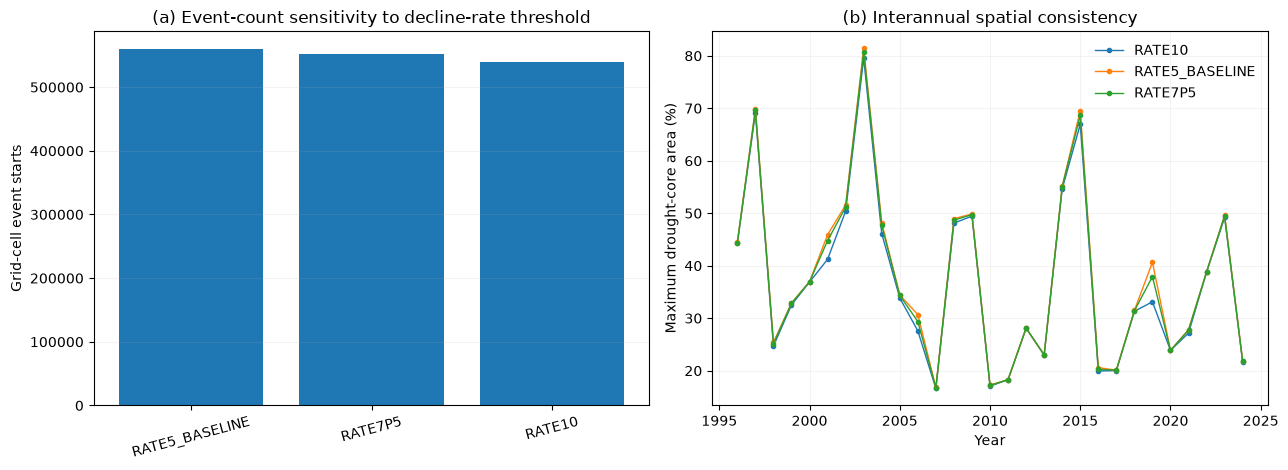

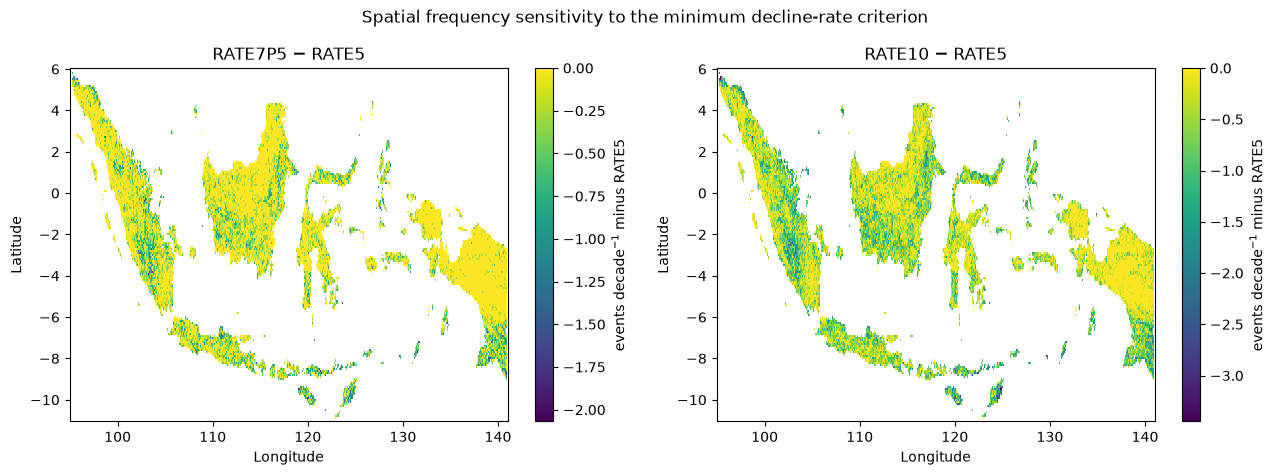

In [6]:
n_years = ANALYSIS_END - ANALYSIS_START + 1

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.8),
)

# Event-count sensitivity.
plot_summary = summary.set_index("method").loc[
    ["RATE5_BASELINE", "RATE7P5", "RATE10"]
]

axes[0].bar(
    plot_summary.index,
    plot_summary["gridcell_event_starts_1996_2024"],
)
axes[0].set(
    ylabel="Grid-cell event starts",
    title="(a) Event-count sensitivity to decline-rate threshold",
)
axes[0].tick_params(axis="x", rotation=15)
axes[0].grid(axis="y", alpha=0.15)

# Annual core extent.
for name, group in annual.groupby("method"):
    axes[1].plot(
        group["year"],
        group["maximum_drought_core_area_percent"],
        marker="o",
        markersize=3,
        linewidth=1,
        label=name,
    )

axes[1].set(
    xlabel="Year",
    ylabel="Maximum drought-core area (%)",
    title="(b) Interannual spatial consistency",
)
axes[1].grid(alpha=0.15)
axes[1].legend(frameon=False)

fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "figure_rate_sensitivity_summary.png",
    dpi=FIG_DPI,
    bbox_inches="tight",
)
plt.show()

# Spatial difference from RATE5.
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.8),
)

for ax, name in zip(
    axes,
    ["RATE7P5", "RATE10"],
):
    diff = (
        (
            freq_maps[name]
            - freq_maps["RATE5_BASELINE"]
        )
        / n_years
        * 10.0
    )

    im = ax.pcolormesh(
        diff["longitude"],
        diff["latitude"],
        diff.where(valid),
        shading="auto",
    )

    fig.colorbar(
        im,
        ax=ax,
        label="events decade$^{-1}$ minus RATE5",
    )

    ax.set(
        xlabel="Longitude",
        ylabel="Latitude",
        title=f"{name} − RATE5",
    )

fig.suptitle(
    "Spatial frequency sensitivity to the minimum decline-rate criterion"
)
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "figure_rate_frequency_differences.png",
    dpi=FIG_DPI,
    bbox_inches="tight",
)
plt.show()


## Interpretation

Report the sensitivity in layers:

1. **absolute frequency sensitivity** — how much the number of grid-cell starts changes;
2. **event identity** — event-start and drought-core Jaccard overlap;
3. **continuous spatial structure** — spatial frequency Spearman correlation;
4. **upper-tail hotspot stability** — Q90 hotspot Jaccard;
5. **interannual structure** — whether the same major years remain prominent.

A stricter rate threshold may reduce event counts substantially while preserving the
broad spatial and interannual pattern. That would support **structural robustness**
but not invariance of absolute frequency.


In [7]:
manifest = {
    "notebook": "03h_SENSITIVITY_DECLINE_RATE_5_7p5_10",
    "benchmark": {
        "label": "RATE5_BASELINE",
        "decline_rate_pp_per_pentad": 5.0,
        "source": str(BASELINE_FILE),
    },
    "variants_pp_per_pentad": [7.5, 10.0],
    "held_constant": {
        "P_start": START_THRESHOLD,
        "P_drought": DROUGHT_THRESHOLD,
        "max_onset_pentads": MAX_ONSET_PENTADS,
        "strict_monotonic": STRICT_MONOTONIC,
        "minimum_total_duration_intervals": MIN_TOTAL_DURATION,
        "initial_P20_persistence_pentads": PERSISTENCE_PENTADS,
        "recovery_pentads": RECOVERY_PENTADS,
    },
    "purpose": "definition sensitivity / robustness, not independent validation",
}

(
    OUTPUT_DIR
    / "manifest_03h_rate_sensitivity.json"
).write_text(
    json.dumps(manifest, indent=2),
    encoding="utf-8",
)

for name, ds_method in datasets.items():
    if ds_method is not baseline:
        ds_method.close()

baseline.close()
pct_ds.close()

print("03h decline-rate sensitivity complete:", OUTPUT_DIR)


03h decline-rate sensitivity complete: D:\ERA5_LAND\output_fd_03h_rate_sensitivity
